In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult

In [2]:
ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params
import list_maps_plots
import circle_results_tools as crt

## 1. Define analysis inputs

Edit these values if needed.

In [3]:
# Example placeholders: edit to your current values
name_file = "LVM-30Dor-6563"
catalog_path = "fits_ready/circle_catalog.csv"
filelist_path = "fits_ready/filelist.txt"

# These should already exist in your notebook/session:
# MAPS_DIR
# results_comp
# wcs
# radius = 413 * u.arcsec
# pc = ...

## 2. Load the list of exported circle names

In [4]:
with open(filelist_path, "r", encoding="utf-8") as f:
    names = [line.strip() for line in f if line.strip()]

names[:5], len(names)

(['LVM-30Dor-6563_A',
  'LVM-30Dor-6563_B1',
  'LVM-30Dor-6563_B2',
  'LVM-30Dor-6563_B3',
  'LVM-30Dor-6563_B4'],
 143)

## 3. Load all bundles

In [5]:
bundles = {}
for name in names:
    bundles[name] = results_comp.load_line_bundle(name, name, MAPS_DIR, read_header=True)

dfs_obs  = {name: bundle["obs"]  for name, bundle in bundles.items()}
dfs_fit  = {name: bundle["fit"]  for name, bundle in bundles.items()}
meta_all = {name: bundle["meta"] for name, bundle in bundles.items()}

## 4. Load the circle catalog

In [6]:
circles_df, circles = crt.load_circle_catalog(catalog_path, name_file)
circles_df.head()

,label,ring,angle_deg,ra_deg,dec_deg,radius_arcsec,name
0,A,A,NaN,84.675000,-69.100000,206.5,LVM-30Dor-6563_A
1,B1,B,0.000000,84.675000,-68.985278,206.5,LVM-30Dor-6563_B1
2,B2,B,51.428571,84.925606,-69.028289,206.5,LVM-30Dor-6563_B2
3,B3,B,102.857143,84.988887,-69.125242,206.5,LVM-30Dor-6563_B3
4,B4,B,154.285714,84.815193,-69.203304,206.5,LVM-30Dor-6563_B4


## 5. Build the one-row-per-circle summary table

In [7]:
pc = meta_all['LVM-30Dor-6563_A']['PC']
radius_arcsec = circles[0]['radius_arcsec']

results_df = crt.build_circle_results_df(
    circles,
    dfs_fit,
    radius_arcsec=radius_arcsec,
    pc=pc,
    param_row=0,
)

In [8]:
results_df

,name,label,ring,angle_deg,ra_deg,dec_deg,radius_arcsec,sig2,r0,m,s0,noise,sig,radius_pc
0,LVM-30Dor-6563_A,A,A,NaN,84.675000,-69.100000,206.5,203.426589,13.094386,2.000000,0.024241,1.940718e+01,14.262769,0.000000
1,LVM-30Dor-6563_B1,B1,B,0.000000,84.675000,-68.985278,206.5,31.751638,7.957265,1.724612,0.024241,1.913656e+00,5.634859,100.114025
2,LVM-30Dor-6563_B2,B2,B,51.428571,84.925606,-69.028289,206.5,20.724171,13.164486,1.416080,0.363610,4.872533e-01,4.552381,100.114025
3,LVM-30Dor-6563_B3,B3,B,102.857143,84.988887,-69.125242,206.5,57.614922,14.606042,1.564090,0.363610,2.250244e+00,7.590449,100.114025
4,LVM-30Dor-6563_B4,B4,B,154.285714,84.815193,-69.203304,206.5,152.207072,72.627411,1.106972,0.363610,2.268878e-10,12.337223,100.114025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,LVM-30Dor-6563_H14,H14,H,106.363636,86.856580,-69.312535,206.5,79.932866,15.380669,1.382020,0.363610,1.371210e-08,8.940518,700.798176
139,LVM-30Dor-6563_H15,H15,H,114.545455,86.753611,-69.421212,206.5,37.219695,16.979075,1.267589,0.258895,3.884303e+00,6.100795,700.798176
140,LVM-30Dor-6563_H16,H16,H,122.727273,86.606489,-69.523516,206.5,7.950916,11.940174,1.105340,0.363610,1.043958e-07,2.819737,700.798176
141,LVM-30Dor-6563_H17,H17,H,130.909091,86.417752,-69.617256,206.5,129.388778,90.793494,0.967335,0.363610,1.322807e-07,11.374919,700.798176


## 6. Sky plot of fitted values inside the circles

In [9]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization.wcsaxes.patches import SphericalCircle

c0 = SkyCoord.from_name("Tarantula")
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

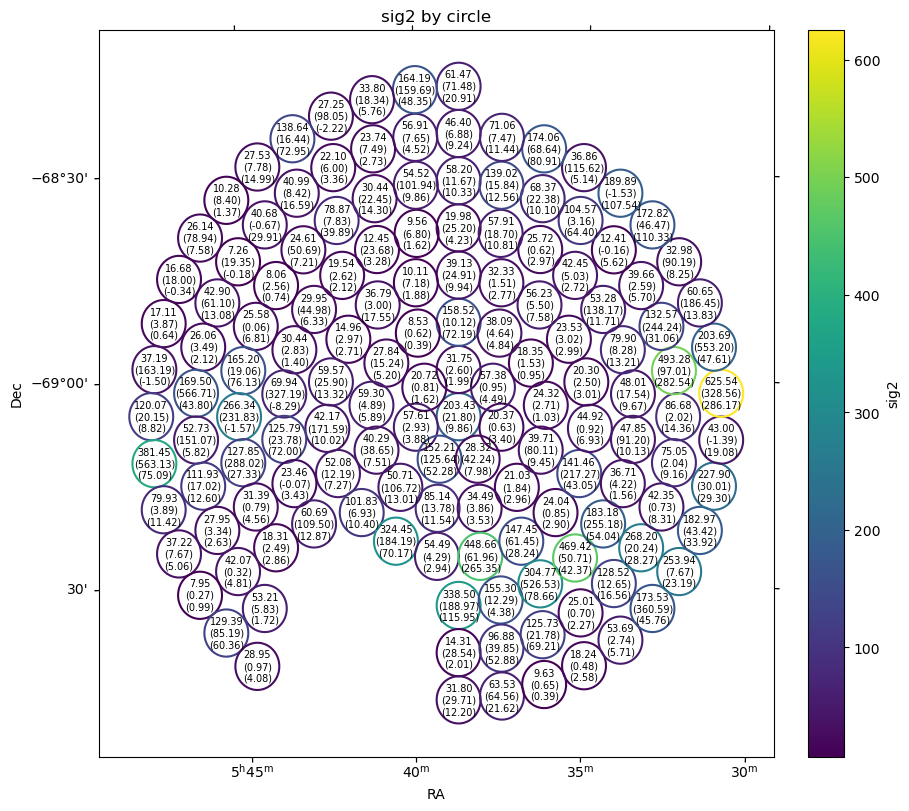

In [10]:
fig, ax = crt.plot_circle_fit_map(
    wcs,
    circles,
    dfs_fit,
    param="sig2",
    title="sig2 by circle",
    cmap="viridis",
    figsize=(9, 8),
    fontsize=7,
)

Try the same for `r0` and `m`.

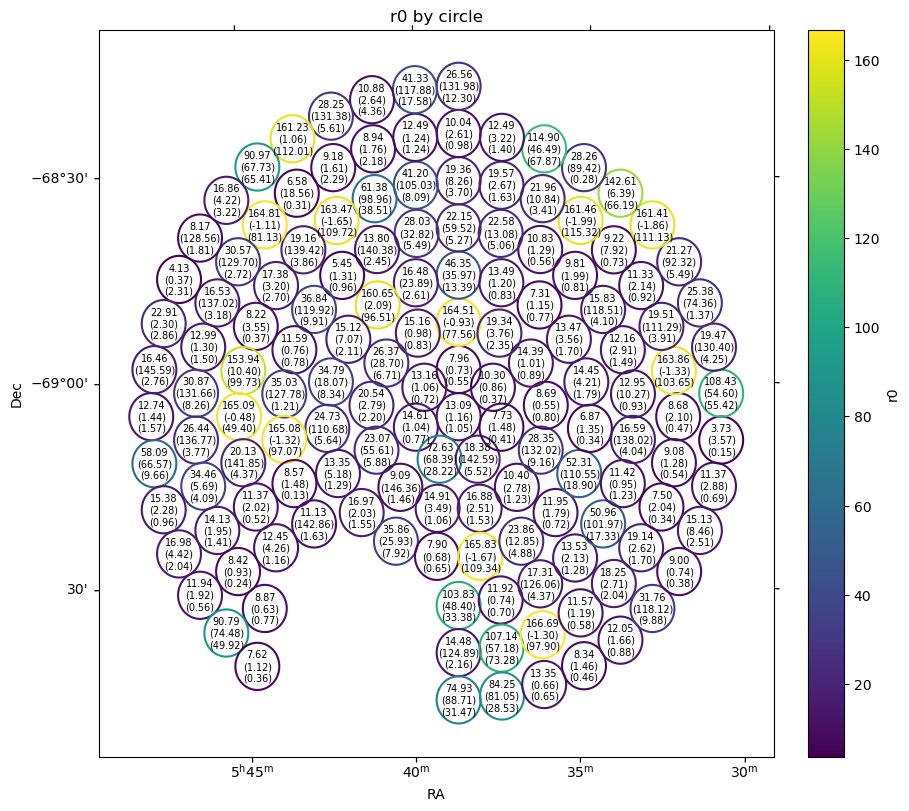

In [11]:
fig, ax = crt.plot_circle_fit_map(
    wcs,
    circles,
    dfs_fit,
    param="r0",
    title="r0 by circle",
    cmap="viridis",
    figsize=(9, 8),
    fontsize=7,
)

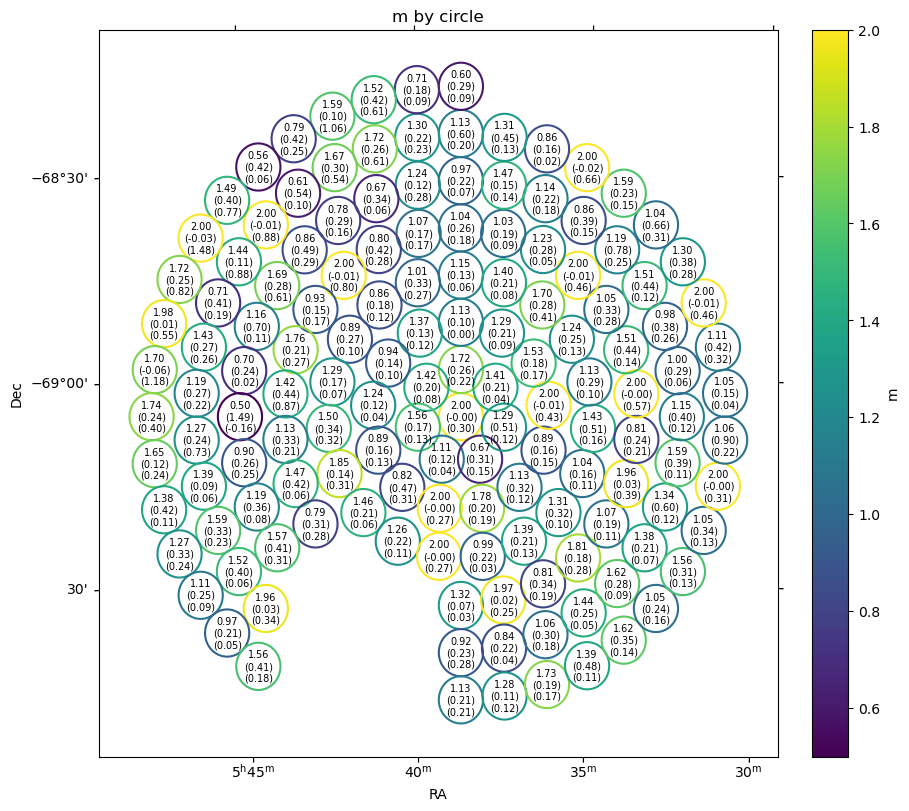

In [12]:
fig, ax = crt.plot_circle_fit_map(
    wcs,
    circles,
    dfs_fit,
    param="m",
    title="m by circle",
    cmap="viridis",
    figsize=(9, 8),
    fontsize=7,
)

## 7. Ring-level statistics

In [13]:
stats_sig_ring = crt.compute_group_stats(results_df, "sig", group_col="ring", order=["center", "inner", "middle", "outer"])
stats_sig_ring

,ring,count,mean,std,median
0,NaN,1,14.262769,NaN,14.262769
1,NaN,7,6.789217,2.760106,5.634859
2,NaN,13,6.410175,2.452188,6.171843
3,NaN,19,8.191913,4.710818,6.702304
4,NaN,23,8.589988,4.989315,6.928630
5,NaN,28,8.874749,4.458337,8.465727
6,NaN,34,8.853551,4.687538,7.278342
7,NaN,18,7.580656,4.276131,5.956414


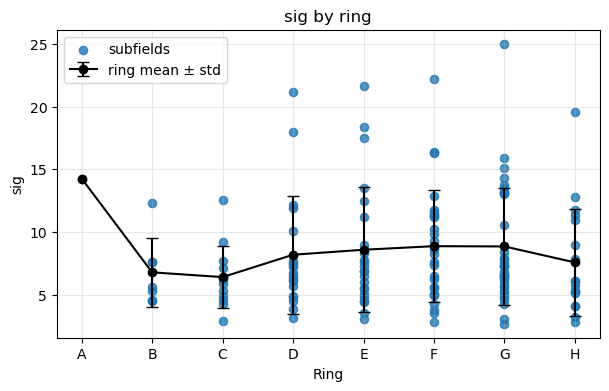

In [14]:
fig, ax, stats_df = crt.plot_parameter_by_ring(
    results_df,
    "sig",
    title="sig by ring",
    ylabel="sig",
)

## 8. Radius-in-pc version

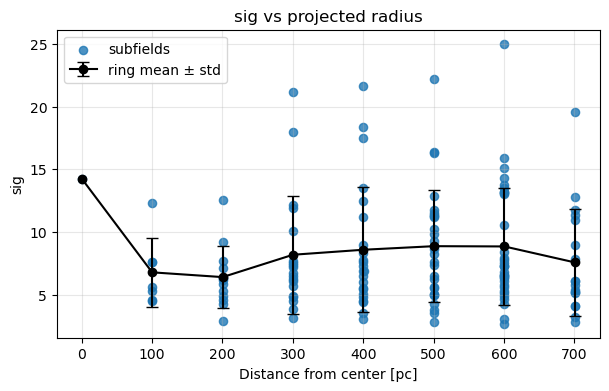

In [15]:
fig, ax, stats_df = crt.plot_parameter_by_radius(
    results_df,
    "sig",
    title="sig vs projected radius",
    ylabel="sig",
    jitter=0.02,
)

## 9. Repeat for `r0` and `m`

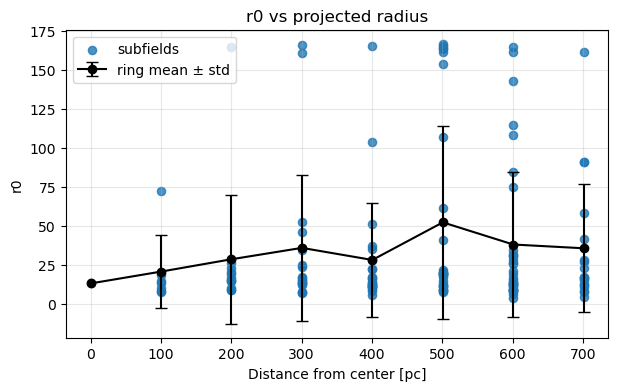

In [16]:
fig, ax, stats_df = crt.plot_parameter_by_radius(
    results_df,
    "r0",
    title="r0 vs projected radius",
    ylabel="r0",
    jitter=0.02,
)

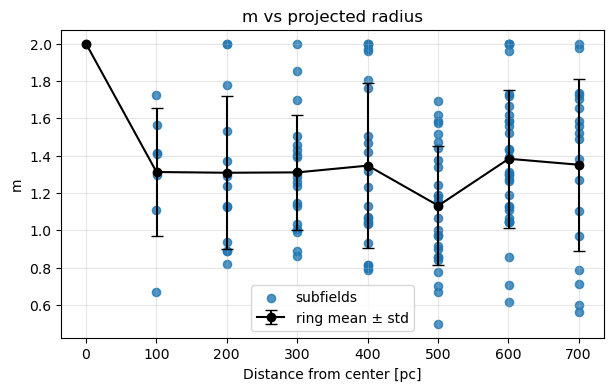

In [17]:
fig, ax, stats_df = crt.plot_parameter_by_radius(
    results_df,
    "m",
    title="m vs projected radius",
    ylabel="m",
    jitter=0.02,
)